In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib import pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [51]:
# columns_to_drop = ['item_size']
# df = df.drop(columns=columns_to_drop)

In [52]:
df[df['shipment_classified']== '']

,quantity_in,bill_date,due_date,eta,seal,customs_broker,receipt_date,ocean_freight,yield_percentage,shipment_classified


In [53]:
df.columns

Index(['quantity_in', 'bill_date', 'due_date', 'eta', 'seal', 'customs_broker',
       'receipt_date', 'ocean_freight', 'yield_percentage',
       'shipment_classified'],
      dtype='object')

In [54]:
# df['payment_terms'] = df['payment_terms'].astype(str).str.lower().str.strip()

In [55]:
# --- 1️⃣ Copy dataframe ---
df_encoded = df.copy()

# --- 2️⃣ Encode binary column ---
# df_encoded['inventory'] = df_encoded['inventory'].map({'Yes': 1, 'No': 0})

# df_encoded['status'] = df_encoded['status'].map({'Active': 1, 'Inactive': 0})

# df_encoded['sales_account'] = df_encoded['sales_account'].map({'1410873000000000388': 1, '1410873000025511653	': 0})

# --- 3️⃣ Encode target column ---
df_encoded['shipment_classified'] = df_encoded['shipment_classified'].map({'on_time': 0, 'delayed': 1})

# --- 4️⃣ Convert date columns ---
date_columns = ['eta','due_date','bill_date',]  # 'receipt_date' will only be placed after shipment is received
for col in date_columns:
    df_encoded[col] = pd.to_datetime(df_encoded[col], errors='coerce')

# --- 5️⃣ Create derived time features ---
for col in date_columns:
  df_encoded[f'{col}_year'] = df_encoded[f'{col}'].dt.year
  df_encoded[f'{col}_year'] = df_encoded[f'{col}_year'].astype('str')
  df_encoded[f'{col}_month'] = df_encoded[f'{col}'].dt.month
  df_encoded[f'{col}_month'] = df_encoded[f'{col}_month'].astype('str')
  df_encoded[f'{col}_day'] = df_encoded[col].dt.day
  df_encoded[f'{col}_day'] = df_encoded[f'{col}_day'].astype('str')
  df_encoded[f'{col}_weekday'] = df_encoded[f'{col}'].dt.weekday
  df_encoded[f'{col}_weekday'] = df_encoded[f'{col}_weekday'].astype('str')

# df_encoded['shipment_duration'] = (pd.to_datetime(df_encoded['receipt_date']) - pd.to_datetime(df_encoded['bill_date'])).dt.days
# df['expected_delay'] = (pd.to_datetime(df['receipt_date']) - pd.to_datetime(df['eta'])).dt.days
df_encoded['due_gap'] = (pd.to_datetime(df_encoded['due_date']) - pd.to_datetime(df_encoded['bill_date'])).dt.days
# df['weekday_bill'] = pd.to_datetime(df['bill_date']).dt.weekday
# df['month_bill'] = pd.to_datetime(df['bill_date']).dt.month

# df_encoded['shipped_day'] = df_encoded['shipped_date'].dt.day
# df_encoded['shipped_month'] = df_encoded['shipped_date'].dt.month
# df_encoded['shipped_year'] = df_encoded['shipped_date'].dt.year
# df_encoded['shipped_weekday'] = df_encoded['shipped_date'].dt.weekday

# --- 6️⃣ Shipping delay feature ---
# df_encoded['delay_days'] = (df_encoded['eta'] - df_encoded['shipped_date']).dt.days

# # --- 7️⃣ Drop raw date columns ---
df_encoded.drop(date_columns + ['receipt_date'], axis=1, inplace=True)

# these feature engineering cannot be applied due to high missing values
# df_encoded['value_per_unit'] = df_encoded['purchase_price'] / df_encoded['quantity_in']
# df_encoded['profit_margin'] = (df_encoded['sales_price'] - df_encoded['purchase_price']) / df_encoded['purchase_price']
# df_encoded['stock_after_shipment'] = df_encoded['opening_stock'] - df_encoded['quantity_in']

df_encoded['broker_frequency'] = df_encoded['customs_broker'].map(df_encoded['customs_broker'].value_counts())

df_encoded.drop(['customs_broker'], axis=1, inplace=True)

# --- 8️⃣ Handle categorical columns ---
categorical_cols = [ 'seal']
from sklearn.preprocessing import LabelEncoder

for col in categorical_cols:
    if df_encoded[col].nunique() > 100:  
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    else:
        df_encoded = pd.get_dummies(df_encoded, columns=[col], drop_first=True, dtype=int)


# --- 9️⃣ Scale numeric features (optional for ML models like logistic regression) ---
# numeric_cols = ['discount', 'delay_days']
# scaler = StandardScaler()
# df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# # --- 🔟 Final encoded dataset ---
# print(df_encoded.head())

# X, y split for training
X = df_encoded.drop('shipment_classified', axis=1)
y = df_encoded['shipment_classified']


In [56]:
df_encoded.isna().sum()[df_encoded.isna().sum() > 0]

Series([], dtype: int64)

In [57]:
# df['opening_stock'].describe()

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1785 entries, 0 to 1784
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   quantity_in          1785 non-null   float64
 1   bill_date            1785 non-null   object 
 2   due_date             1785 non-null   object 
 3   eta                  1785 non-null   object 
 4   seal                 1785 non-null   object 
 5   customs_broker       1785 non-null   object 
 6   receipt_date         1785 non-null   object 
 7   ocean_freight        1785 non-null   float64
 8   yield_percentage     1785 non-null   float64
 9   shipment_classified  1785 non-null   object 
dtypes: float64(3), object(7)
memory usage: 139.6+ KB


In [59]:
# Step 2: Data preprocessing
# df['inventory'] = df['inventory'].map({'Yes': 1, 'No': 0})
# df['shipment_classified'] = df['shipment_classified'].map({'on_time': 0, 'delayed': 1})

In [60]:
# Encode categorical columns
# cat_cols = df.select_dtypes(include=['object']).columns
# le = LabelEncoder()
# for col in cat_cols:
#     df[col] = le.fit_transform(df[col])

In [61]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1785 entries, 0 to 1784
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   quantity_in          1785 non-null   float64
 1   seal                 1785 non-null   int64  
 2   ocean_freight        1785 non-null   float64
 3   yield_percentage     1785 non-null   float64
 4   shipment_classified  1785 non-null   int64  
 5   eta_year             1785 non-null   object 
 6   eta_month            1785 non-null   object 
 7   eta_day              1785 non-null   object 
 8   eta_weekday          1785 non-null   object 
 9   due_date_year        1785 non-null   object 
 10  due_date_month       1785 non-null   object 
 11  due_date_day         1785 non-null   object 
 12  due_date_weekday     1785 non-null   object 
 13  bill_date_year       1785 non-null   object 
 14  bill_date_month      1785 non-null   object 
 15  bill_date_day        1785 non-null   o

In [62]:
# # Step 3: Split features & target
# X = df.drop('shipment_classified', axis=1)
# y = df['shipment_classified']

In [63]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [64]:
df_encoded

,quantity_in,seal,ocean_freight,yield_percentage,shipment_classified,eta_year,eta_month,eta_day,eta_weekday,due_date_year,due_date_month,due_date_day,due_date_weekday,bill_date_year,bill_date_month,bill_date_day,bill_date_weekday,due_gap,broker_frequency
0,35280.0,871,5800.00,78.0,0,2025,10,6,0,2025,10,9,3,2025,10,9,3,0,420
1,34020.0,988,6900.00,91.0,0,2025,10,6,0,2025,10,7,1,2025,10,7,1,0,420
2,35280.0,214,4218.00,105.0,0,2025,10,3,4,2025,10,7,1,2025,10,7,1,0,40
3,38000.0,864,7100.64,0.0,0,2025,10,6,0,2025,10,18,5,2025,10,8,2,10,420
4,34020.0,954,7300.00,78.0,0,2025,10,6,0,2025,10,7,1,2025,10,7,1,0,420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1780,30600.0,661,0.00,78.0,0,2019,9,13,4,2019,10,15,1,2019,8,16,4,60,47
1781,30600.0,271,0.00,78.0,1,2019,9,28,5,2019,10,18,4,2019,8,19,0,60,136
1782,36000.0,19,0.00,99.0,0,2019,9,23,0,2019,8,14,2,2019,8,14,2,0,708
1783,33750.0,255,0.00,86.0,1,2019,9,28,5,2019,10,13,6,2019,8,14,2,60,136


In [65]:
# Step 5: Scale features
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [66]:
# Step 6: Train model
model = LogisticRegression(class_weight = "balanced", max_iter=1000)
model.fit(X_train, y_train)

/Users/prashant/.pyenv/versions/ideabox-env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [67]:
print(model.classes_)

[0 1]


In [68]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi = mutual_info_classif(X, y)
pd.Series(mi, index=X.columns).sort_values(ascending=False)

seal                 0.099728
eta_weekday          0.043796
quantity_in          0.025264
bill_date_month      0.020929
eta_month            0.019379
eta_day              0.019193
ocean_freight        0.017151
bill_date_day        0.011734
due_date_year        0.009146
due_gap              0.008800
broker_frequency     0.005138
due_date_day         0.004488
eta_year             0.002817
due_date_weekday     0.001398
bill_date_year       0.000000
bill_date_weekday    0.000000
yield_percentage     0.000000
due_date_month       0.000000
dtype: float64

In [69]:
# Step 7: Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5798319327731093

Confusion Matrix:
 [[173 120]
 [ 30  34]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.59      0.70       293
           1       0.22      0.53      0.31        64

    accuracy                           0.58       357
   macro avg       0.54      0.56      0.50       357
weighted avg       0.74      0.58      0.63       357



In [70]:
# Optional: Feature importance
importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
print("\nTop features influencing delay:\n", importance.head(10))



Top features influencing delay:
 eta_month           0.113396
due_date_weekday    0.040639
due_date_year       0.007718
bill_date_year      0.005249
yield_percentage    0.002954
broker_frequency    0.000675
ocean_freight       0.000120
quantity_in         0.000014
seal               -0.000151
bill_date_day      -0.001153
dtype: float64


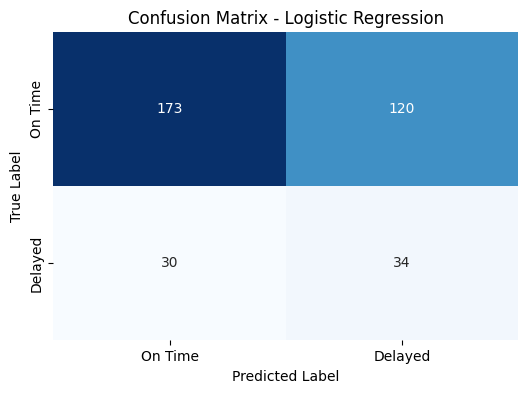

In [71]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

<Axes: xlabel='shipment_classified'>

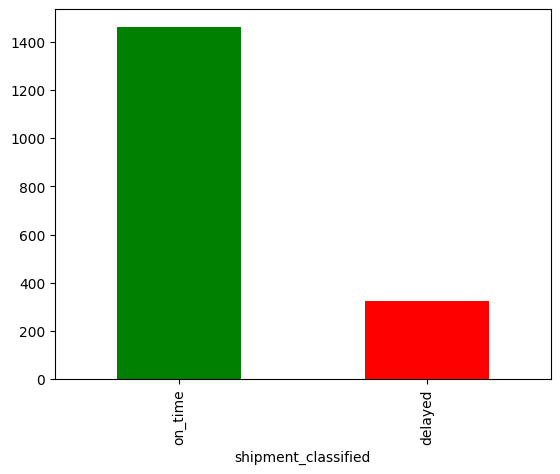

In [72]:
df['shipment_classified'].value_counts().plot(kind='bar', color=['green', 'red'])